# UNSW-NB15 Final IGL1 Notebook (Leakage-Aware, Final Design, Reviewer-Aligned)

Notebook ini adalah **versi final yang dibekukan** untuk kebutuhan **resubmission**. Desainnya dibuat agar:
- **selaras dengan reviewer**,
- **valid secara metodologis**,
- **menghindari data leakage**,
- dan **konsisten dengan manuscript final**.

Keputusan desain yang dipakai:
- dataset: `UNSW_NB15_training-set.csv`
- **reduced six-class setting**
- drop `label`
- drop `id`
- split **train / validation / test** terlebih dahulu
- encoding kategorikal berbasis **training only**
- scaling berbasis **training only**
- **tanpa oversampling** pada final reported run
- IGL1:
  - Information Gain keep ratio = **0.75**
  - L1-Regularised LinearSVC `C = 0.005`
  - final subset = **top-21 features after L1 sparse ranking**
- **main models**:
  - MLP + IGL1
  - Gradient Boosting + IGL1
  - Random Forest + IGL1
- **supporting baseline models**:
  - SVM + IGL1
  - KNN + IGL1

Notebook ini juga menghasilkan:
- validation results
- test results
- FPR/FNR table
- confusion matrix
- ROC curve
- comparison vs Yin et al. [22]
- artifact untuk manuscript/rebuttal


In [4]:

# Mount Google Drive (Colab)
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:

from pathlib import Path
import json, time, warnings, joblib, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, label_binarize
from sklearn.feature_selection import SelectKBest, mutual_info_classif, SelectFromModel
from sklearn.svm import LinearSVC, SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

warnings.filterwarnings("ignore")

print("Python:", platform.python_version())
try:
    import torch
    print("Torch CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
except Exception as e:
    print("Torch info unavailable:", e)


Python: 3.12.13
Torch CUDA available: True
GPU: NVIDIA A100-SXM4-80GB



## 1. Konfigurasi final yang dibekukan
Konfigurasi di bawah ini adalah versi final yang disarankan untuk resubmission.


In [6]:

RANDOM_STATE = 42

# Dataset task definition
TARGET_COL = "attack_cat"
DROP_LABEL_COLUMN = True
DROP_ID_FEATURE = True
USE_REDUCED_SIX_CLASS = True
MINORITY_CLASSES_TO_REMOVE = ["Analysis", "Backdoor", "Shellcode", "Worms"]

# Split: 68 / 16 / 16
TEMP_SIZE = 0.32
VAL_FROM_TEMP = 0.50

# Final frozen preprocessing
SCALER_NAME = "minmax"
USE_OVERSAMPLING = False  # dibekukan: tidak memakai oversampling

# Final frozen IGL1 configuration
BEST_IG_KEEP_RATIO = 0.75
BEST_L1_C = 0.005
LINEARSVC_MAX_ITER = 10000
USE_TOPK_FINAL_FEATURES = True
TARGET_FINAL_FEATURES = 21

# Final frozen main-model configurations
BEST_MLP_PARAMS = {
    "hidden_layer_sizes": (100, 50),
    "activation": "relu",
    "alpha": 0.001,
    "learning_rate_init": 0.005,
    "max_iter": 500,
    "early_stopping": True
}

BEST_GB_PARAMS = {
    "n_estimators": 200,
    "learning_rate": 0.1,
    "max_depth": 3,
    "subsample": 0.8
}

# Supporting baselines
RF_N_ESTIMATORS = 100
SVM_KERNEL = "rbf"
KNN_K = 5

# Artifacts
ARTIFACT_DIR = Path("/content/drive/MyDrive/artifacts_igl1_final")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Artifacts will be saved to:", ARTIFACT_DIR.resolve())


Artifacts will be saved to: /content/drive/MyDrive/artifacts_igl1_final



## 2. Helper functions


In [7]:

def compute_macro_fpr_fnr(y_true, y_pred, labels=None):
    """
    Macro-averaged one-vs-rest FPR and FNR for multi-class classification.
    """
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fpr_list, fnr_list = [], []
    total = cm.sum()

    for i in range(cm.shape[0]):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = total - (TP + FN + FP)

        fpr = FP / (FP + TN) if (FP + TN) > 0 else 0.0
        fnr = FN / (FN + TP) if (FN + TP) > 0 else 0.0

        fpr_list.append(fpr)
        fnr_list.append(fnr)

    return float(np.mean(fpr_list)), float(np.mean(fnr_list)), cm

def evaluate_model(model, X_eval, y_eval, model_name="Model"):
    y_pred = model.predict(X_eval)

    acc = accuracy_score(y_eval, y_pred)
    prec = precision_score(y_eval, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_eval, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_eval, y_pred, average='weighted', zero_division=0)
    fpr, fnr, cm = compute_macro_fpr_fnr(y_eval, y_pred)

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "fpr": fpr,
        "fnr": fnr,
        "y_pred": y_pred,
        "confusion_matrix": cm
    }

def print_metrics(result_dict):
    print(f"\n=== {result_dict['model']} ===")
    print(f"Accuracy : {result_dict['accuracy']:.4f}")
    print(f"Precision: {result_dict['precision']:.4f}")
    print(f"Recall   : {result_dict['recall']:.4f}")
    print(f"F1-score : {result_dict['f1']:.4f}")
    print(f"FPR      : {result_dict['fpr']:.4f}")
    print(f"FNR      : {result_dict['fnr']:.4f}")

def get_scaler(name):
    if name == "minmax":
        return MinMaxScaler()
    raise ValueError(f"Unsupported frozen scaler: {name}")



## 3. Temukan dan muat dataset
Notebook ini akan mencari `UNSW_NB15_training-set.csv` di beberapa path umum Colab/Drive.


In [8]:

candidate_paths = []
search_dirs = [
    Path('.'),
    Path('/mnt/data'),
    Path('/content'),
    Path('/content/drive/MyDrive/DATASET/UNSW-NB15/Training and Testing Sets/')
]
patterns = ['*UNSW_NB15_training-set.csv']

for base in search_dirs:
    if base.exists():
        for pattern in patterns:
            candidate_paths.extend(base.glob(pattern))

candidate_paths = sorted({p.resolve() for p in candidate_paths})
print("Candidate dataset paths:")
for p in candidate_paths[:20]:
    print("-", p)

if len(candidate_paths) == 0:
    raise FileNotFoundError("UNSW-NB15 training CSV not found. Please upload the dataset or update the search path.")

DATA_PATH = candidate_paths[0]
print("\nUsing dataset:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
print("Initial shape:", df.shape)
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nInitial class distribution:")
display(df[TARGET_COL].value_counts(dropna=False).to_frame("count"))


Candidate dataset paths:
- /content/drive/MyDrive/DATASET/UNSW-NB15/Training and Testing Sets/UNSW_NB15_training-set.csv

Using dataset: /content/drive/MyDrive/DATASET/UNSW-NB15/Training and Testing Sets/UNSW_NB15_training-set.csv
Initial shape: (175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0



Columns:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

Initial class distribution:


,count
attack_cat,
Normal,56000
Generic,40000
Exploits,33393
Fuzzers,18184
DoS,12264
Reconnaissance,10491
Analysis,2000
Backdoor,1746
Shellcode,1133



## 4. Cleaning dan definisi task


In [9]:

if DROP_LABEL_COLUMN and 'label' in df.columns:
    df = df.drop(columns=['label'])
    print("Dropped column: label")

if DROP_ID_FEATURE and 'id' in df.columns:
    df = df.drop(columns=['id'])
    print("Dropped column: id (non-behavioral identifier feature)")

null_count = int(df.isnull().sum().sum())
print("Total missing values:", null_count)
if null_count > 0:
    df = df.dropna().copy()
    print("Dropped rows with missing values. New shape:", df.shape)

if USE_REDUCED_SIX_CLASS:
    before_shape = df.shape
    df = df[~df[TARGET_COL].isin(MINORITY_CLASSES_TO_REMOVE)].copy()
    print(f"Reduced six-class setting active. Shape: {before_shape} -> {df.shape}")
    display(df[TARGET_COL].value_counts().to_frame("count"))
else:
    print("All classes retained.")


Dropped column: label
Dropped column: id (non-behavioral identifier feature)
Total missing values: 0
Reduced six-class setting active. Shape: (175341, 43) -> (170332, 43)


,count
attack_cat,
Normal,56000
Generic,40000
Exploits,33393
Fuzzers,18184
DoS,12264
Reconnaissance,10491



## 5. Pisahkan feature/target, split, dan target encoding


In [10]:

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Candidate input features:")
print(X.columns.tolist())

categorical_cols = [c for c in ['proto', 'service', 'state'] if c in X.columns]
print("Categorical columns for binary encoding:", categorical_cols)

# Train / validation / test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=TEMP_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=VAL_FROM_TEMP,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

print("\nTrain class distribution:")
display(y_train.value_counts().to_frame("count"))
print("\nValidation class distribution:")
display(y_val.value_counts().to_frame("count"))
print("\nTest class distribution:")
display(y_test.value_counts().to_frame("count"))

# Encode target from training only
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)
print("Label classes:", list(label_encoder.classes_))


Feature matrix shape: (170332, 42)
Target shape: (170332,)
Candidate input features:
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']
Categorical columns for binary encoding: ['proto', 'service', 'state']
Train: (115825, 42) (115825,)
Val  : (27253, 42) (27253,)
Test : (27254, 42) (27254,)

Train class distribution:


,count
attack_cat,
Normal,38080
Generic,27200
Exploits,22707
Fuzzers,12365
DoS,8339
Reconnaissance,7134



Validation class distribution:


,count
attack_cat,
Normal,8960
Generic,6400
Exploits,5343
Fuzzers,2909
DoS,1962
Reconnaissance,1679



Test class distribution:


,count
attack_cat,
Normal,8960
Generic,6400
Exploits,5343
Fuzzers,2910
DoS,1963
Reconnaissance,1678


Label classes: ['DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance']



## 6. Training-driven binary encoding untuk fitur kategorikal


In [11]:

dominant_map = {}
for col in categorical_cols:
    dominant_map[col] = X_train[col].mode(dropna=True)[0]

print("Dominant category map (training-driven):", dominant_map)

def binary_encode_features(df_in, dominant_map):
    df_out = df_in.copy()
    for col, dominant_value in dominant_map.items():
        df_out[col] = (df_out[col] == dominant_value).astype(int)
    return df_out

X_train_enc = binary_encode_features(X_train, dominant_map)
X_val_enc = binary_encode_features(X_val, dominant_map)
X_test_enc = binary_encode_features(X_test, dominant_map)

print("Encoded shapes:")
print("Train:", X_train_enc.shape)
print("Val  :", X_val_enc.shape)
print("Test :", X_test_enc.shape)


Dominant category map (training-driven): {'proto': 'tcp', 'service': '-', 'state': 'INT'}
Encoded shapes:
Train: (115825, 42)
Val  : (27253, 42)
Test : (27254, 42)



## 7. Scaling (training only)
Dibekukan memakai **MinMaxScaler** sesuai desain final.


In [12]:

if USE_OVERSAMPLING:
    raise ValueError("Frozen final design does not use oversampling.")

scaler = get_scaler(SCALER_NAME)

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_enc),
    columns=X_train_enc.columns,
    index=X_train_enc.index
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val_enc),
    columns=X_val_enc.columns,
    index=X_val_enc.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_enc),
    columns=X_test_enc.columns,
    index=X_test_enc.index
)

print("Scaling completed without leakage.")
print("Train scaled shape:", X_train_scaled.shape)


Scaling completed without leakage.
Train scaled shape: (115825, 42)



## 8. IGL1 feature selection (final configuration)
- IG keep ratio = **0.75**
- L1 C = **0.005**
- final subset = **top-21 features** based on L1 sparse importance after IG


In [13]:

# Step 1: Information Gain
n_features_ig = max(1, int(X_train_scaled.shape[1] * BEST_IG_KEEP_RATIO))
selector_ig = SelectKBest(score_func=mutual_info_classif, k=n_features_ig)

X_train_ig = selector_ig.fit_transform(X_train_scaled, y_train_enc)
X_val_ig = selector_ig.transform(X_val_scaled)
X_test_ig = selector_ig.transform(X_test_scaled)

selected_features_ig = X_train_scaled.columns[selector_ig.get_support()].tolist()

print("Number of features after IG:", len(selected_features_ig))
print(selected_features_ig)

# Step 2: L1-Regularised LinearSVC + top-k retention
lsvc = LinearSVC(
    C=BEST_L1_C,
    penalty='l1',
    dual=False,
    random_state=RANDOM_STATE,
    max_iter=LINEARSVC_MAX_ITER
)

selector_l1 = SelectFromModel(
    lsvc,
    threshold=-np.inf,
    max_features=TARGET_FINAL_FEATURES
)

X_train_ig_df = pd.DataFrame(X_train_ig, columns=selected_features_ig, index=X_train_scaled.index)
X_val_ig_df = pd.DataFrame(X_val_ig, columns=selected_features_ig, index=X_val_scaled.index)
X_test_ig_df = pd.DataFrame(X_test_ig, columns=selected_features_ig, index=X_test_scaled.index)

X_train_igl1 = selector_l1.fit_transform(X_train_ig_df, y_train_enc)
X_val_igl1 = selector_l1.transform(X_val_ig_df)
X_test_igl1 = selector_l1.transform(X_test_ig_df)

selected_features_igl1 = [
    selected_features_ig[i] for i in selector_l1.get_support(indices=True)
]

print("\nNumber of final IGL1 features:", len(selected_features_igl1))
print("Final selected features:")
print(selected_features_igl1)

final_features_df = pd.DataFrame({
    "No": range(1, len(selected_features_igl1) + 1),
    "Final_Selected_Feature": selected_features_igl1
})
display(final_features_df)


Number of features after IG: 31
['dur', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_src_ltm', 'ct_srv_dst']

Number of final IGL1 features: 21
Final selected features:
['dur', 'service', 'state', 'spkts', 'dpkts', 'sttl', 'dttl', 'sload', 'dload', 'sinpkt', 'tcprtt', 'synack', 'smean', 'dmean', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_src_ltm', 'ct_srv_dst']


,No,Final_Selected_Feature
0,1,dur
1,2,service
2,3,state
3,4,spkts
4,5,dpkts
5,6,sttl
6,7,dttl
7,8,sload
8,9,dload
9,10,sinpkt



## 9. Visualisasi feature importance (IG + L1)


,Feature,IG,L1_Coefficient
12,smean,0.914365,0.391385
7,sload,0.886994,0.141745
13,dmean,0.545094,0.206049
0,dur,0.532799,0.274340
18,ct_dst_sport_ltm,0.521887,0.242799
20,ct_srv_dst,0.509254,1.153682
15,ct_state_ttl,0.501452,0.374197
6,dttl,0.497250,0.565449
14,ct_srv_src,0.484487,0.581283
5,sttl,0.477803,0.493494


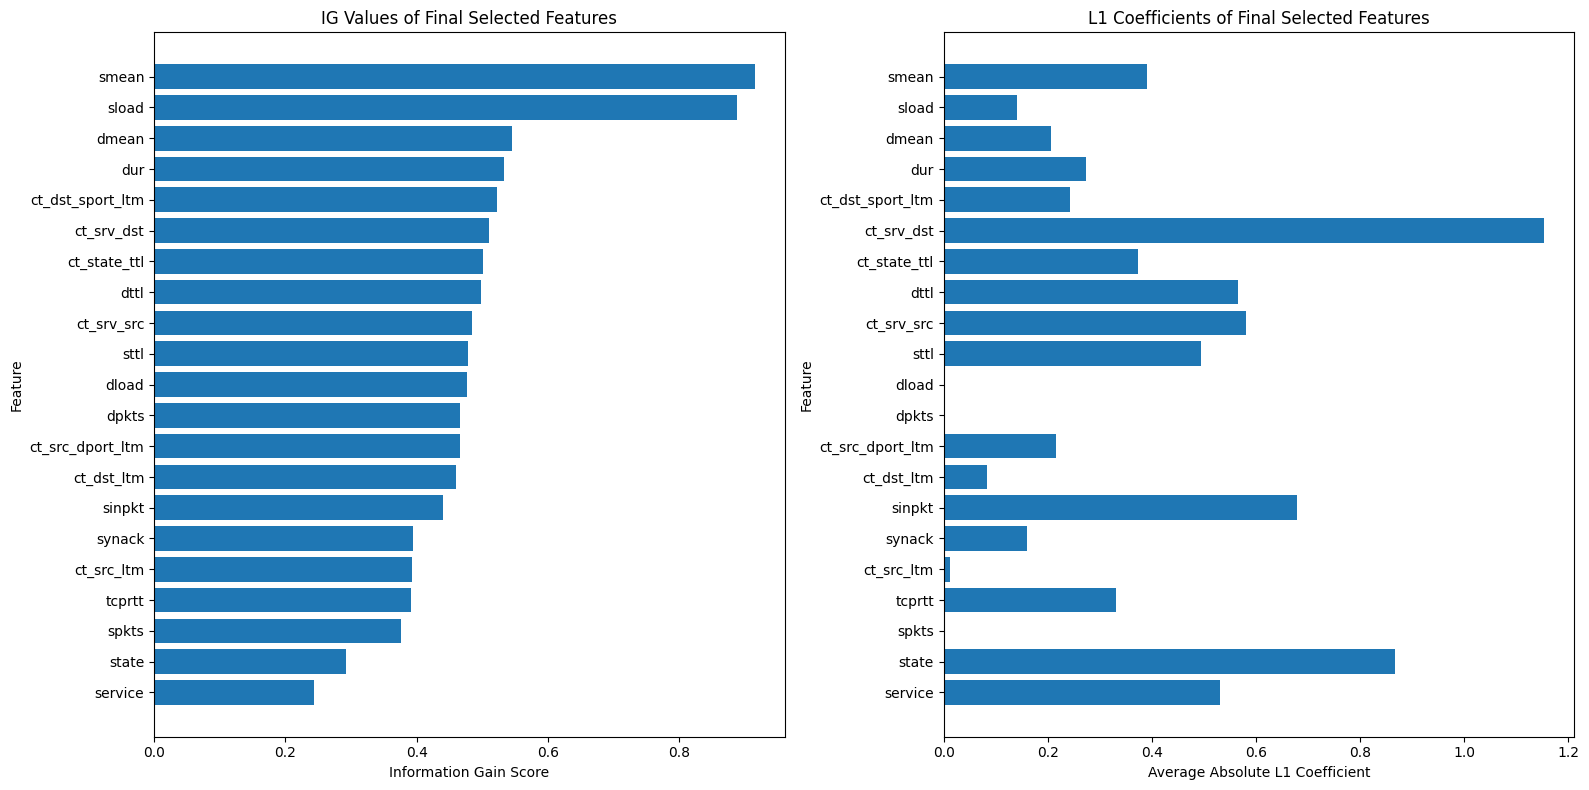

In [14]:

information_gain = selector_ig.scores_
ig_map = dict(zip(X_train_scaled.columns, information_gain))

l1_importance = np.mean(np.abs(selector_l1.estimator_.coef_), axis=0)
l1_map = dict(zip(selected_features_ig, l1_importance))

combined_df = pd.DataFrame({
    'Feature': selected_features_igl1,
    'IG': [ig_map[f] for f in selected_features_igl1],
    'L1_Coefficient': [l1_map[f] for f in selected_features_igl1]
}).sort_values(by='IG', ascending=False)

display(combined_df)

combined_plot_df = combined_df.sort_values(by='IG', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(combined_plot_df['Feature'], combined_plot_df['IG'])
axes[0].set_xlabel('Information Gain Score')
axes[0].set_ylabel('Feature')
axes[0].set_title('IG Values of Final Selected Features')

axes[1].barh(combined_plot_df['Feature'], combined_plot_df['L1_Coefficient'])
axes[1].set_xlabel('Average Absolute L1 Coefficient')
axes[1].set_ylabel('Feature')
axes[1].set_title('L1 Coefficients of Final Selected Features')

plt.tight_layout()
plt.show()


## 10. Train **main models** with best parameters

Tiga model utama yang dievaluasi pada naskah final adalah **MLP**, **Gradient Boosting**, dan **Random Forest**.

In [15]:

results_val = []
models = {}

# MLP (main model)
mlp = MLPClassifier(
    hidden_layer_sizes=BEST_MLP_PARAMS["hidden_layer_sizes"],
    activation=BEST_MLP_PARAMS["activation"],
    alpha=BEST_MLP_PARAMS["alpha"],
    learning_rate_init=BEST_MLP_PARAMS["learning_rate_init"],
    max_iter=BEST_MLP_PARAMS["max_iter"],
    early_stopping=BEST_MLP_PARAMS["early_stopping"],
    random_state=RANDOM_STATE
)
start = time.time()
mlp.fit(X_train_igl1, y_train_enc)
mlp_train_time = time.time() - start
models["MLP + IGL1"] = mlp
res = evaluate_model(mlp, X_val_igl1, y_val_enc, "MLP + IGL1")
res["train_time_sec"] = mlp_train_time
results_val.append(res)
print_metrics(res)
print("Training time:", round(mlp_train_time, 2), "s")

# Gradient Boosting (main model)
gb = GradientBoostingClassifier(
    n_estimators=BEST_GB_PARAMS["n_estimators"],
    learning_rate=BEST_GB_PARAMS["learning_rate"],
    max_depth=BEST_GB_PARAMS["max_depth"],
    subsample=BEST_GB_PARAMS["subsample"],
    random_state=RANDOM_STATE
)
start = time.time()
gb.fit(X_train_igl1, y_train_enc)
gb_train_time = time.time() - start
models["Gradient Boosting + IGL1"] = gb
res = evaluate_model(gb, X_val_igl1, y_val_enc, "Gradient Boosting + IGL1")
res["train_time_sec"] = gb_train_time
results_val.append(res)
print_metrics(res)
print("Training time:", round(gb_train_time, 2), "s")

# Random Forest (main model based on strongest empirical performance)
rf = RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, random_state=RANDOM_STATE)
start = time.time()
rf.fit(X_train_igl1, y_train_enc)
rf_train_time = time.time() - start
models["Random Forest + IGL1"] = rf
res = evaluate_model(rf, X_val_igl1, y_val_enc, "Random Forest + IGL1")
res["train_time_sec"] = rf_train_time
results_val.append(res)
print_metrics(res)
print("Training time:", round(rf_train_time, 2), "s")



=== MLP + IGL1 ===
Accuracy : 0.8346
Precision: 0.8342
Recall   : 0.8346
F1-score : 0.8284
FPR      : 0.0333
FNR      : 0.2556
Training time: 199.19 s

=== Gradient Boosting + IGL1 ===
Accuracy : 0.8399
Precision: 0.8330
Recall   : 0.8399
F1-score : 0.8231
FPR      : 0.0329
FNR      : 0.2688
Training time: 334.27 s

=== Random Forest + IGL1 ===
Accuracy : 0.8454
Precision: 0.8418
Recall   : 0.8454
F1-score : 0.8394
FPR      : 0.0314
FNR      : 0.2511
Training time: 17.56 s


## 11. Train **remaining supporting baseline models**

Model pendukung yang tetap dipakai untuk memeriksa generalisasi subset fitur adalah **SVM** dan **KNN**.

In [16]:

# SVM (supporting baseline)
svm = SVC(kernel=SVM_KERNEL, probability=True, random_state=RANDOM_STATE)
start = time.time()
svm.fit(X_train_igl1, y_train_enc)
svm_train_time = time.time() - start
models["SVM + IGL1"] = svm
res = evaluate_model(svm, X_val_igl1, y_val_enc, "SVM + IGL1")
res["train_time_sec"] = svm_train_time
results_val.append(res)
print_metrics(res)
print("Training time:", round(svm_train_time, 2), "s")

# KNN (supporting baseline)
knn = KNeighborsClassifier(n_neighbors=KNN_K)
start = time.time()
knn.fit(X_train_igl1, y_train_enc)
knn_train_time = time.time() - start
models["KNN + IGL1"] = knn
res = evaluate_model(knn, X_val_igl1, y_val_enc, "KNN + IGL1")
res["train_time_sec"] = knn_train_time
results_val.append(res)
print_metrics(res)
print("Training time:", round(knn_train_time, 2), "s")

results_val_df = pd.DataFrame(results_val).drop(columns=["y_pred","confusion_matrix"]).sort_values(by="f1", ascending=False)
display(results_val_df)

best_validation_model = results_val_df.iloc[0]["model"]
print("Best validation model among all evaluated models:", best_validation_model)



=== SVM + IGL1 ===
Accuracy : 0.7670
Precision: 0.7848
Recall   : 0.7670
F1-score : 0.7465
FPR      : 0.0469
FNR      : 0.3868
Training time: 1237.68 s

=== KNN + IGL1 ===
Accuracy : 0.8166
Precision: 0.8228
Recall   : 0.8166
F1-score : 0.8192
FPR      : 0.0366
FNR      : 0.2681
Training time: 0.01 s


,model,accuracy,precision,recall,f1,fpr,fnr,train_time_sec
2,Random Forest + IGL1,0.845412,0.841760,0.845412,0.839424,0.031365,0.251067,17.558065
0,MLP + IGL1,0.834624,0.834179,0.834624,0.828419,0.033330,0.255556,199.186103
1,Gradient Boosting + IGL1,0.839908,0.832957,0.839908,0.823087,0.032943,0.268836,334.269637
4,KNN + IGL1,0.816607,0.822848,0.816607,0.819231,0.036599,0.268058,0.012229
3,SVM + IGL1,0.766961,0.784799,0.766961,0.746467,0.046857,0.386831,1237.676670


Best validation model among all evaluated models: Random Forest + IGL1



## 12. Final evaluation on test set


In [17]:

final_results_test = []

for name, model in models.items():
    res = evaluate_model(model, X_test_igl1, y_test_enc, name)
    train_time = float(results_val_df.loc[results_val_df['model'] == name, 'train_time_sec'].values[0])
    res["train_time_sec"] = train_time
    final_results_test.append(res)
    print_metrics(res)
    print("Training time:", round(train_time, 2), "s")

final_results_test_df = pd.DataFrame(final_results_test).drop(columns=["y_pred","confusion_matrix"]).sort_values(by="f1", ascending=False)
display(final_results_test_df)

main_model_names = ['MLP + IGL1', 'Gradient Boosting + IGL1', 'Random Forest + IGL1']
table4_main_df = final_results_test_df[
    final_results_test_df['model'].isin(main_model_names)
][['model', 'fnr', 'fpr']].copy().rename(columns={'model':'Model','fnr':'FNR','fpr':'FPR'})

print("\nTable 4 candidate (main models only):")
display(table4_main_df)



=== MLP + IGL1 ===
Accuracy : 0.8322
Precision: 0.8302
Recall   : 0.8322
F1-score : 0.8259
FPR      : 0.0338
FNR      : 0.2620
Training time: 199.19 s

=== Gradient Boosting + IGL1 ===
Accuracy : 0.8389
Precision: 0.8298
Recall   : 0.8389
F1-score : 0.8218
FPR      : 0.0332
FNR      : 0.2732
Training time: 334.27 s

=== Random Forest + IGL1 ===
Accuracy : 0.8432
Precision: 0.8397
Recall   : 0.8432
F1-score : 0.8376
FPR      : 0.0319
FNR      : 0.2562
Training time: 17.56 s

=== SVM + IGL1 ===
Accuracy : 0.7705
Precision: 0.7790
Recall   : 0.7705
F1-score : 0.7491
FPR      : 0.0461
FNR      : 0.3841
Training time: 1237.68 s

=== KNN + IGL1 ===
Accuracy : 0.8156
Precision: 0.8218
Recall   : 0.8156
F1-score : 0.8181
FPR      : 0.0369
FNR      : 0.2721
Training time: 0.01 s


,model,accuracy,precision,recall,f1,fpr,fnr,train_time_sec
2,Random Forest + IGL1,0.843179,0.839750,0.843179,0.837580,0.031877,0.256183,17.558065
0,MLP + IGL1,0.832245,0.830179,0.832245,0.825899,0.033810,0.261976,199.186103
1,Gradient Boosting + IGL1,0.838886,0.829804,0.838886,0.821798,0.033168,0.273158,334.269637
4,KNN + IGL1,0.815623,0.821815,0.815623,0.818083,0.036870,0.272066,0.012229
3,SVM + IGL1,0.770529,0.778985,0.770529,0.749141,0.046139,0.384127,1237.676670



Table 4 candidate (main models only):


,Model,FNR,FPR
2,Random Forest + IGL1,0.256183,0.031877
0,MLP + IGL1,0.261976,0.033810
1,Gradient Boosting + IGL1,0.273158,0.033168



## 13. Confusion matrix dan ROC untuk best test model


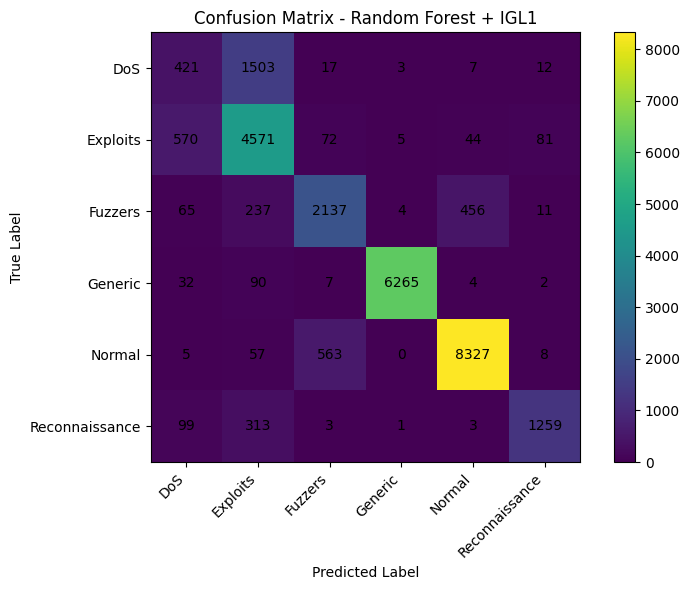

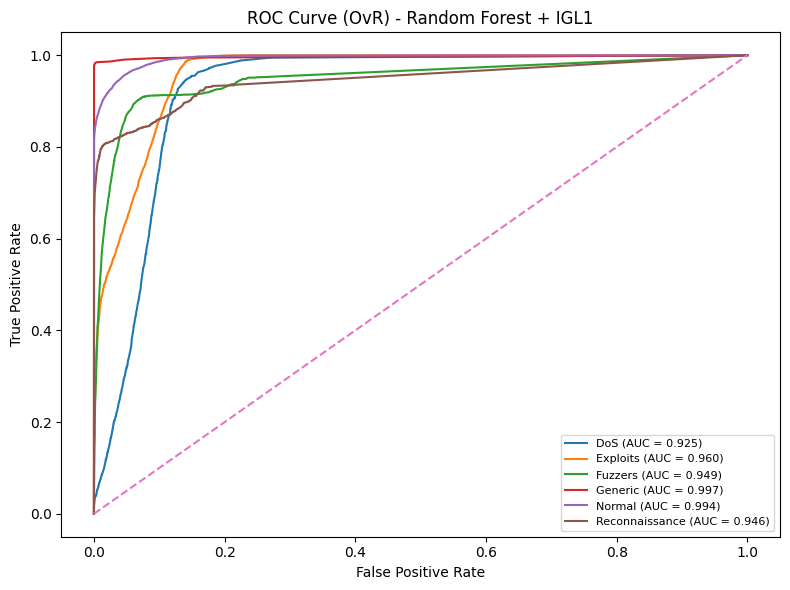

,class,auc
0,DoS,0.925345
1,Exploits,0.960236
2,Fuzzers,0.949156
3,Generic,0.996574
4,Normal,0.993774
5,Reconnaissance,0.946322


In [18]:

best_test_model_name = final_results_test_df.iloc[0]["model"]
best_test_model = models[best_test_model_name]
best_test_eval = evaluate_model(best_test_model, X_test_igl1, y_test_enc, best_test_model_name)
cm = best_test_eval["confusion_matrix"]

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest')
plt.title(f'Confusion Matrix - {best_test_model_name}')
plt.colorbar()
tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=45, ha='right')
plt.yticks(tick_marks, label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

if hasattr(best_test_model, "predict_proba"):
    y_score = best_test_model.predict_proba(X_test_igl1)
elif hasattr(best_test_model, "decision_function"):
    y_score = best_test_model.decision_function(X_test_igl1)
else:
    y_score = None

if y_score is None:
    print("Best model does not support predict_proba/decision_function. ROC skipped.")
else:
    y_test_bin = label_binarize(y_test_enc, classes=np.arange(len(label_encoder.classes_)))

    plt.figure(figsize=(8, 6))
    roc_rows = []
    for i, class_name in enumerate(label_encoder.classes_):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr_i, tpr_i)
        roc_rows.append({"class": class_name, "auc": roc_auc})
        plt.plot(fpr_i, tpr_i, label=f"{class_name} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (OvR) - {best_test_model_name}")
    plt.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()

    roc_auc_df = pd.DataFrame(roc_rows)
    display(roc_auc_df)



## 14. Comparison vs Yin et al. [22]
Menggunakan benchmark yang selama ini Anda pakai di tabel pembanding:
- Accuracy = **0.8424**
- F1 = **0.8285**


In [19]:

yin_accuracy = 0.8424
yin_f1 = 0.8285

yin_rows = []
for _, row in final_results_test_df.iterrows():
    yin_rows.append({
        "model": row["model"],
        "accuracy": row["accuracy"],
        "f1": row["f1"],
        "delta_accuracy_vs_yin": row["accuracy"] - yin_accuracy,
        "delta_f1_vs_yin": row["f1"] - yin_f1
    })

yin_comparison_df = pd.DataFrame(yin_rows).sort_values(by="delta_f1_vs_yin", ascending=False)
display(yin_comparison_df)


,model,accuracy,f1,delta_accuracy_vs_yin,delta_f1_vs_yin
0,Random Forest + IGL1,0.843179,0.837580,0.000779,0.009080
1,MLP + IGL1,0.832245,0.825899,-0.010155,-0.002601
2,Gradient Boosting + IGL1,0.838886,0.821798,-0.003514,-0.006702
3,KNN + IGL1,0.815623,0.818083,-0.026777,-0.010417
4,SVM + IGL1,0.770529,0.749141,-0.071871,-0.079359


## 15. Summary and save artifacts

Ringkasan ini akan menjadi dasar untuk pembekuan angka final pada manuscript dan response to reviewers.

In [20]:

print("=== Key Summary ===")
print("Scaler               :", SCALER_NAME)
print("Oversampling         :", USE_OVERSAMPLING)
print("Best IGL1 keep ratio :", BEST_IG_KEEP_RATIO)
print("Best L1 C            :", BEST_L1_C)
print("Features after IG    :", len(selected_features_ig))
print("Final features       :", len(selected_features_igl1))
print("Final feature list   :", selected_features_igl1)

print("\nValidation results:")
display(results_val_df)

print("\nTest results:")
display(final_results_test_df)

summary_payload = {
    "data_path": str(DATA_PATH),
    "reduced_six_class": USE_REDUCED_SIX_CLASS,
    "drop_id_feature": DROP_ID_FEATURE,
    "scaler_name": SCALER_NAME,
    "use_oversampling": USE_OVERSAMPLING,
    "best_ig_keep_ratio": BEST_IG_KEEP_RATIO,
    "best_l1_c": BEST_L1_C,
    "use_topk_final_features": USE_TOPK_FINAL_FEATURES,
    "target_final_features": TARGET_FINAL_FEATURES,
    "dominant_map": dominant_map,
    "selected_features_ig": selected_features_ig,
    "selected_features_igl1": selected_features_igl1,
    "best_mlp_params": BEST_MLP_PARAMS,
    "best_gb_params": BEST_GB_PARAMS,
    "validation_results": results_val_df.to_dict(orient='records'),
    "test_results": final_results_test_df.to_dict(orient='records'),
    "best_validation_model": best_validation_model,
    "best_test_model": best_test_model_name
}

with open(ARTIFACT_DIR / 'run_summary.json', 'w') as f:
    json.dump(summary_payload, f, indent=2)

joblib.dump(label_encoder, ARTIFACT_DIR / 'label_encoder_unsw_nb15.pkl')
joblib.dump(scaler, ARTIFACT_DIR / 'scaler_unsw_nb15.pkl')
joblib.dump(selector_ig, ARTIFACT_DIR / 'selector_ig_unsw_nb15.pkl')
joblib.dump(selector_l1, ARTIFACT_DIR / 'selector_l1_unsw_nb15.pkl')
joblib.dump(models[best_test_model_name], ARTIFACT_DIR / 'best_model_unsw_nb15.pkl')

final_features_df.to_csv(ARTIFACT_DIR / 'final_selected_features.csv', index=False)
combined_df.to_csv(ARTIFACT_DIR / 'final_feature_importance_ig_l1.csv', index=False)
results_val_df.to_csv(ARTIFACT_DIR / 'validation_results.csv', index=False)
final_results_test_df.to_csv(ARTIFACT_DIR / 'test_results.csv', index=False)
table4_main_df.to_csv(ARTIFACT_DIR / 'table4_fpr_fnr_main_models.csv', index=False)
yin_comparison_df.to_csv(ARTIFACT_DIR / 'yin_comparison.csv', index=False)

print("Artifacts saved to:", ARTIFACT_DIR.resolve())


=== Key Summary ===
Scaler               : minmax
Oversampling         : False
Best IGL1 keep ratio : 0.75
Best L1 C            : 0.005
Features after IG    : 31
Final features       : 21
Final feature list   : ['dur', 'service', 'state', 'spkts', 'dpkts', 'sttl', 'dttl', 'sload', 'dload', 'sinpkt', 'tcprtt', 'synack', 'smean', 'dmean', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_src_ltm', 'ct_srv_dst']

Validation results:


,model,accuracy,precision,recall,f1,fpr,fnr,train_time_sec
2,Random Forest + IGL1,0.845412,0.841760,0.845412,0.839424,0.031365,0.251067,17.558065
0,MLP + IGL1,0.834624,0.834179,0.834624,0.828419,0.033330,0.255556,199.186103
1,Gradient Boosting + IGL1,0.839908,0.832957,0.839908,0.823087,0.032943,0.268836,334.269637
4,KNN + IGL1,0.816607,0.822848,0.816607,0.819231,0.036599,0.268058,0.012229
3,SVM + IGL1,0.766961,0.784799,0.766961,0.746467,0.046857,0.386831,1237.676670



Test results:


,model,accuracy,precision,recall,f1,fpr,fnr,train_time_sec
2,Random Forest + IGL1,0.843179,0.839750,0.843179,0.837580,0.031877,0.256183,17.558065
0,MLP + IGL1,0.832245,0.830179,0.832245,0.825899,0.033810,0.261976,199.186103
1,Gradient Boosting + IGL1,0.838886,0.829804,0.838886,0.821798,0.033168,0.273158,334.269637
4,KNN + IGL1,0.815623,0.821815,0.815623,0.818083,0.036870,0.272066,0.012229
3,SVM + IGL1,0.770529,0.778985,0.770529,0.749141,0.046139,0.384127,1237.676670


Artifacts saved to: /content/drive/MyDrive/artifacts_igl1_final


## 16. Cara menjalankan
1. Pastikan file `UNSW_NB15_training-set.csv` ada di Google Drive / path yang dibaca notebook.
2. Buka notebook di Colab.
3. Pilih **Runtime > Restart and run all**.
4. Setelah selesai, ambil output berikut untuk tahap revisi paper:
   - `selected_features_igl1`
   - `results_val_df`
   - `final_results_test_df`
   - `table4_main_df`
   - `yin_comparison_df`
5. Gunakan hasil tersebut sebagai **satu-satunya sumber kebenaran** untuk manuscript final.

Catatan penting:
- **Random Forest + IGL1** diposisikan sebagai **main model** bersama **MLP + IGL1** dan **Gradient Boosting + IGL1** karena hasil empirisnya paling kuat.
- **SVM + IGL1** dan **KNN + IGL1** diposisikan sebagai **supporting baselines**.
- Final subset 21 fitur harus dijelaskan di manuscript sebagai **top-21 features retained after L1 sparse ranking**, bukan sekadar non-zero coefficients.
